# **Ejercicio Opcional APIs**

Trabajar con Excels y CSVs descargados está bien para empezar, pero en el mundo real los datos cambian constantemente. Las APIs sirven para conectar nuestro código en Python directamente a bases de datos externas y extraer información actualizada.

Cada API tiene sus reglas. Algunas son de pago, otras requieren claves de acceso y todas organizan la información de manera distinta. Por eso, la principal habilidad al usar una API es leer su documentación. Vamos a usar la [PokéAPI](https://pokeapi.co/docs/v2), una base de datos pública y sin registro.

## El Reto: Registro Civil de Kanto

Tu trabajo es generar el Carnet de Identidad de los Pokémon que traen los entrenadores. Para ello no puedes fiarte de la memoria del entrenador, tienes que conectarte a la API, extraer los datos del Pokémon, limpiarlos y guardarlos y generar el documento de identidad.

Tu primer cliente quiere registrar a su Pikachu.

### Paso 1: La URL y la petición (requests.get)

Para pedirle información a la API, necesitamos la dirección exacta. Esta URL se construye uniendo tres partes en este caso:

1. URL Base (https://pokeapi.co/api/v2/): La raíz de la API. Todas las peticiones empiezan aquí.

2. Endpoint (pokemon): La categoría de datos que estamos consultando.

3. Recurso (pikachu): La entrada exacta que queremos buscar dentro de esa categoría.

Puedes revisar la documentación para identificar los endpoint y los recursos. También para comprobar la estructura en la que se guardan los datos, muy importante para luego extraer la verdadera información.

In [2]:
import requests
import pandas as pd

endpoint = "pokemon"
recurso = "pikachu"

url = f"https://pokeapi.co/api/v2/{endpoint}/{recurso}"
datos_pikachu = requests.get(url)

Usamos la función requests.get() para hacer la consulta. Esta función no nos da los datos inmediatamente, sino una respuesta. Puedes probar haciendo un print del tipo. Si el código de estado de esa respuesta es 200, significa que la conexión ha sido un éxito y podemos proceder a leer los datos.

In [3]:
# Comprobamos el código de estado (200 = OK, 404 = No encontrado)
print(type(datos_pikachu), datos_pikachu)

<class 'requests.models.Response'> <Response [200]>


### Paso 2: Desempaquetar los datos (.json())

La variable datos_pikachu de nuestro paso anterior contiene la respuesta del servidor, pero no los datos legibles. Para extraer la información real, usa el método .json() y guárdalo en una variable llamada json_pikachu.

In [4]:
# .json() convierte la respuesta del servidor en un diccionario de Python
# Es el paso que transforma datos "crudos" en algo que podemos manejar
json_pikachu = datos_pikachu.json()

# Vemos las claves principales para hacernos una idea de qué nos ha dado la API
print("Claves principales:")
print(list(json_pikachu.keys()))

Claves principales:
['abilities', 'base_experience', 'cries', 'forms', 'game_indices', 'height', 'held_items', 'id', 'is_default', 'location_area_encounters', 'moves', 'name', 'order', 'past_abilities', 'past_stats', 'past_types', 'species', 'sprites', 'stats', 'types', 'weight']


Como ves, la API nos devuelve una cantidad absurda de información. 

Pero para nuestro Carnet de Identidad Pokémon, sólo necesitamos estos datos clave:

1. ID

2. Nombre

3. Tipo 1 y Tipo 2

4. Las 6 estadísticas base (HP, Ataque, Defensa, Ataque Especial, Defensa Especial, Velocidad)

5. Peso (weight) y Altura (height)

6. La imagen oficial del pokemon.

7. La descripción de su especie.

8. Una de sus habilidades.

### Paso 3: Pasando los datos a Pandas

Nuestra herramienta de trabajo final es un DataFrame. 
Crea un DataFrame desde el json_pikachu, puedes usar el constructor propio de DataFrame o el método json_normalize() de pandas.
Una vez lo hagás, haz un head().

In [4]:
# pd.json_normalize() "aplana" el JSON y lo convierte en un DataFrame
# Es mejor que pd.DataFrame() para JSONs complejos con datos anidados - Gracias Claude IA <3 
df_pikachu = pd.json_normalize(json_pikachu)
df_pikachu.head()

,abilities,base_experience,forms,game_indices,height,held_items,id,is_default,location_area_encounters,moves,...,sprites.versions.generation-vii.icons.front_default,sprites.versions.generation-vii.icons.front_female,sprites.versions.generation-vii.ultra-sun-ultra-moon.front_default,sprites.versions.generation-vii.ultra-sun-ultra-moon.front_female,sprites.versions.generation-vii.ultra-sun-ultra-moon.front_shiny,sprites.versions.generation-vii.ultra-sun-ultra-moon.front_shiny_female,sprites.versions.generation-viii.brilliant-diamond-shining-pearl.front_default,sprites.versions.generation-viii.brilliant-diamond-shining-pearl.front_female,sprites.versions.generation-viii.icons.front_default,sprites.versions.generation-viii.icons.front_female
0,"[{'ability': {'name': 'static', 'url': 'https:...",112,"[{'name': 'pikachu', 'url': 'https://pokeapi.c...","[{'game_index': 84, 'version': {'name': 'red',...",4,"[{'item': {'name': 'oran-berry', 'url': 'https...",25,True,https://pokeapi.co/api/v2/pokemon/25/encounters,"[{'move': {'name': 'mega-punch', 'url': 'https...",...,https://raw.githubusercontent.com/PokeAPI/spri...,None,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,None,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...


El problema de los datos anidados

Si te fijas en la tabla que acabamos de generar, verás algo raro. Hay columnas (como abilities, stats o types) que en lugar de tener un valor simple como "60" o "Electric", tienen listas [...] o más diccionarios {...} metidos en la misma celda.

¿Por qué pasa esto? Porque el JSON original no es plano. Tiene una estructura de árbol: un Pokémon tiene una lista de estadísticas, y cada estadística tiene su propio nombre y valor.

Trabajar con tablas que tienen listas dentro de sus celdas es una dolor para hacer cálculos o gráficos y es lo más normal cuando obtienes la información desde una API.

### Paso 4: Crear una función de limpieza

Como funcionario de Datos en Kanto, no vas a hacer este proceso a mano solo para Pikachu. Tendrás que procesar cientos de solicitudes.

Crea la función procesar_pokemon(json_data). Esta función debe recibir el JSON crudo de cualquier Pokémon y devolver un diccionario limpio con las siguientes claves y condiciones:

1. id, nombre, habilidad, peso y altura.

2. tipo_1 y tipo_2. Si el Pokémon solo tiene un tipo, asígnale el valor None a tipo_2.

3. Una clave por cada una de las 6 estadísticas base (hp, attack, etc.).

4. El enlace de la imagen "front_default" del arte oficial que se encuentra dentro de sprites. Vas a tener que bucear bien dentro del diccionario para encontrarla.

5. La descripción de la especie del pokemon.

Una vez lo tengas pruébalo para crear un DataFrame con todos los valores limpios de Pikachu.

In [5]:
def procesar_pokemon(json_data):
    """
    Recibimos el JSON crudo de un Pokémon y devolvemos un diccionario limpio
    con solo los datos que necesitamos para el Carnet de Identidad.
    """
    # Datos básicos: id, nombre, peso y altura están directamente en el JSON
    datos_limpios = {
        "id": json_data["id"],
        "nombre": json_data["name"],
        "peso": json_data["weight"],
        "altura": json_data["height"]
    }
    
    # Tipos: vienen como una lista de diccionarios anidados
    # json_data["types"] = [{"slot": 1, "type": {"name": "electric"}}, ...]
    # Sacamos el nombre del tipo 1 (siempre existe)
    datos_limpios["tipo_1"] = json_data["types"][0]["type"]["name"]
    
    # El tipo 2 puede no existir (muchos Pokémon solo tienen un tipo)
    if len(json_data["types"]) > 1:
        datos_limpios["tipo_2"] = json_data["types"][1]["type"]["name"]
    else:
        datos_limpios["tipo_2"] = None
    
    # Estadísticas: vienen como una lista de 6 diccionarios
    # Cada uno tiene: {"base_stat": 35, "stat": {"name": "hp"}}
    for stat in json_data["stats"]:
        nombre_stat = stat["stat"]["name"]
        valor_stat = stat["base_stat"]
        datos_limpios[nombre_stat] = valor_stat
    
    # Imagen oficial: está escondida dentro de sprites > other > official-artwork
    datos_limpios["imagen"] = json_data["sprites"]["other"]["official-artwork"]["front_default"]
    
    # Habilidad: cogemos la primera de la lista
    datos_limpios["habilidad_nombre"] = json_data["abilities"][0]["ability"]["name"]
    datos_limpios["habilidad_url"] = json_data["abilities"][0]["ability"]["url"]
    
    # La URL de la especie (para luego pedir la descripción en otro request)
    datos_limpios["species_url"] = json_data["species"]["url"]
    
    return datos_limpios

In [6]:
# Probamos la función con nuestro JSON de Pikachu
datos_pikachu_limpio = procesar_pokemon(json_pikachu)



In [10]:
# Lo convertimos en DataFrame para verlo bonito
# Metemos el diccionario dentro de una lista [] porque DataFrame espera una lista de filas
df_limpio = pd.DataFrame([datos_pikachu_limpio])
df_limpio

,id,nombre,peso,altura,tipo_1,tipo_2,hp,attack,defense,special-attack,special-defense,speed,imagen,habilidad_nombre,habilidad_url,species_url
0,25,pikachu,60,4,electric,None,35,55,40,50,50,90,https://raw.githubusercontent.com/PokeAPI/spri...,static,https://pokeapi.co/api/v2/ability/9/,https://pokeapi.co/api/v2/pokemon-species/25/


### Paso 5 - La descripción de la especie y la habilidad.

Si no te diste cuenta, te lo digo yo. Tanto la biografía de la especie como los detalles de su habilidad no vienen dentro del primer JSON. Lo que nos da la API en su lugar es un enlace (url).

Esto es una práctica estándar en el diseño de APIs. Si el servidor nos mandara toda la biografía en todos los idiomas y el texto de cada habilidad de golpe, la descarga sería enorme y lentísima. Por eficiencia, las APIs te entregan los datos superficiales y te dejan enlaces para que hagas nuevas peticiones solo si realmente necesitas profundizar.

Investiga tu JSON crudo o la documentación de la [PokéAPI](https://pokeapi.co/docs/v2) para encontrar dónde están escondidas esas URLs. Haz las nuevas requests, limpia los datos e introduce el texto de la biografía y de la habilidad en tu diccionario antes de pasarlo al DataFrame.

In [11]:
def obtener_descripcion(species_url):
    """
    Hacemos una SEGUNDA petición a la API para obtener la descripción de la especie.
    La descripción no viene en el JSON del Pokémon, solo viene la URL para pedirla.
    """
    respuesta = requests.get(species_url)
    datos_especie = respuesta.json()
    
    # flavor_text_entries es una lista con descripciones en muchos idiomas
    # Recorremos hasta encontrar una en español ("es")
    for entrada in datos_especie["flavor_text_entries"]:
        if entrada["language"]["name"] == "es":
            # Limpiamos los saltos de línea raros que trae el texto
            texto = entrada["flavor_text"].replace("\n", " ").replace("\f", " ")
            return texto
    
    # Si no hay descripción en español, devolvemos una en inglés
    for entrada in datos_especie["flavor_text_entries"]:
        if entrada["language"]["name"] == "en":
            return entrada["flavor_text"].replace("\n", " ").replace("\f", " ")
    
    return "Descripción no disponible"


def obtener_habilidad(habilidad_url):
    """
    Hacemos OTRA petición para obtener la descripción del efecto de la habilidad.
    """
    respuesta = requests.get(habilidad_url)
    datos_habilidad = respuesta.json()
    
    # effect_entries tiene la descripción del efecto en varios idiomas
    for entrada in datos_habilidad["effect_entries"]:
        if entrada["language"]["name"] == "en":
            return entrada["short_effect"]
    
    return "Efecto no disponible"

In [12]:
# Completamos los datos de Pikachu con la descripción y el efecto de su habilidad
datos_pikachu_limpio["descripcion"] = obtener_descripcion(datos_pikachu_limpio["species_url"])
datos_pikachu_limpio["habilidad_efecto"] = obtener_habilidad(datos_pikachu_limpio["habilidad_url"])

# Actualizamos el DataFrame
df_limpio = pd.DataFrame([datos_pikachu_limpio])
df_limpio

,id,nombre,peso,altura,tipo_1,tipo_2,hp,attack,defense,special-attack,special-defense,speed,imagen,habilidad_nombre,habilidad_url,species_url,descripcion,habilidad_efecto
0,25,pikachu,60,4,electric,None,35,55,40,50,50,90,https://raw.githubusercontent.com/PokeAPI/spri...,static,https://pokeapi.co/api/v2/ability/9/,https://pokeapi.co/api/v2/pokemon-species/25/,Levanta su cola para vigilar los alrededores. ...,Has a 30% chance of paralyzing attacking Pokém...


### Paso 6 - A crear el CIP!

Este paso es el más sencillo. Si tienes tu DataFrame con los datos limpios y listos sólo tienes que rellenar los campos de la función de abajo y comprueba como el CIP de Pikachu ya está listo. Ahora el entrenador de Pikachu ya puede llevarlo al centro pokemon para que le atiendan gratis.

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import requests
from io import BytesIO
import textwrap

def crear_carnet(nombre, pokedex_id, tipo_1, tipo_2, altura, peso, imagen, lista_stats, habilidad_nombre, habilidad_efecto, descripcion):
    """
    Genera un Carné de Identidad usando Matplotlib. Devuelve el objeto Figure.
    Agrupa absolutamente todo el texto en la columna central y elimina la fila inferior.
    """   
    fig = plt.figure(figsize=(14, 7))
    fig.suptitle(f"CARNET DE IDENTIDAD POKEMON: {nombre.upper()}", fontsize=18, fontweight='bold', y=0.95)
        
    grid = fig.add_gridspec(1, 3, width_ratios=[1, 1.3, 1.2])
   
    ax_img = fig.add_subplot(grid[0, 0])
    ax_img.axis('off')
    try:
        respuesta = requests.get(imagen)
        img = mpimg.imread(BytesIO(respuesta.content))
        ax_img.imshow(img)
    except:
        ax_img.text(0.5, 0.5, "Imagen no disponible", ha='center', va='center')
    
    ax_info = fig.add_subplot(grid[0, 1])
    ax_info.axis('off') 
    
    texto_tipo2 = tipo_2.capitalize() if tipo_2 else "-"
        
    ancho_columna = 45
    efecto_wrap = textwrap.fill(habilidad_efecto, width=ancho_columna)
    bio_wrap = textwrap.fill(descripcion, width=ancho_columna)
    
    info_text = (
        f"Nombre: {nombre.capitalize()}\n"
        f"No Pokedex: #{pokedex_id}\n"
        f"Tipo 1: {tipo_1.capitalize()}\n"
        f"Tipo 2: {texto_tipo2}\n"
        f"Altura: {altura/10:.1f} m\n"
        f"Peso: {peso/10:.1f} kg\n\n"
        f"Habilidad: {habilidad_nombre.capitalize()}\n"
        f"{efecto_wrap}\n\n"
        f"Biografia:\n"
        f"{bio_wrap}"
    )
        
    ax_info.text(0.0, 0.5, info_text, fontsize=12, linespacing=1.5, ha='left', va='center')
    
    ax_radar = fig.add_subplot(grid[0, 2], polar=True)
    
    categorias = ['PS', 'Ataque', 'Defensa', 'Atq. Esp.', 'Def. Esp.', 'Velocidad']
    N = len(categorias)
    
    valores = list(lista_stats) + [lista_stats[0]]
    angulos = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
    
    ax_radar.set_theta_offset(np.pi / 2)
    ax_radar.set_theta_direction(-1)
    
    ax_radar.set_xticks(angulos[:-1])
    ax_radar.set_xticklabels(categorias, color='dimgrey', size=11)
    ax_radar.set_rlabel_position(0)
    
    ax_radar.plot(angulos, valores, linewidth=2, linestyle='solid', color='royalblue')
    ax_radar.fill(angulos, valores, color='skyblue', alpha=0.4)
    ax_radar.set_title("Estadisticas Base", size=13, color='black', pad=15)

    plt.tight_layout()
    
    return fig

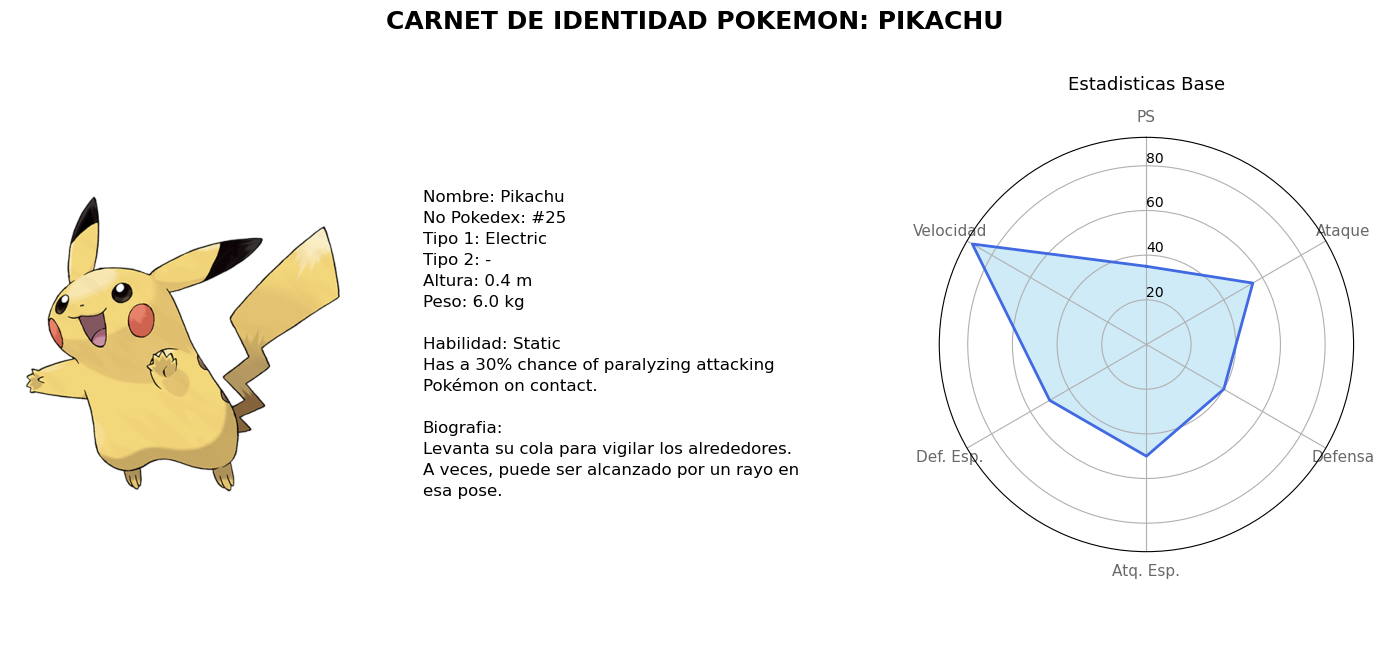

In [14]:
# Sacamos los datos del DataFrame para rellenar la función del carnet
# .iloc[0] nos da la primera (y única) fila
p = df_limpio.iloc[0]

crear_carnet(
    nombre=p["nombre"],
    pokedex_id=p["id"],
    tipo_1=p["tipo_1"],
    tipo_2=p["tipo_2"],
    altura=p["altura"],
    peso=p["peso"],
    imagen=p["imagen"],
    lista_stats=(p["hp"], p["attack"], p["defense"], p["special-attack"], p["special-defense"], p["speed"]),
    habilidad_nombre=p["habilidad_nombre"],
    habilidad_efecto=p["habilidad_efecto"],
    descripcion=p["descripcion"]
);

### Paso 7 - Creando la base de datos de Kanto

Hasta ahora has procesado Carnets de Identidad uno a uno. Pero el Registro Civil necesita digitalizar a los 151 Pokémon originales de la región de Kanto de una sola vez.

Sabes como hacer requests a la API, ahora en vez de traerte los datos de un pokemon tienes que conseguir los de 151.

Además, tienes una función para procesar los datos en bruto del json de un pokemon, asi que utilízala para convertir esos 151 json en un dataframe nuevo hecho y derecho con los 151 pokemon de kanto.

In [18]:
# Recorremos los 151 Pokémon originales de Kanto
lista_pokemon = []

for i in range(1, 152):
    # Pedimos los datos del Pokémon
    url = f"https://pokeapi.co/api/v2/pokemon/{i}"
    respuesta = requests.get(url)
    json_pokemon = respuesta.json()
    
    # Procesamos con nuestra función
    datos = procesar_pokemon(json_pokemon)
    
    # Pedimos la descripción y la habilidad (son peticiones extra)
    datos["descripcion"] = obtener_descripcion(datos["species_url"])
    datos["habilidad_efecto"] = obtener_habilidad(datos["habilidad_url"])
    
    lista_pokemon.append(datos)
    
    # Imprimimos progreso cada 10 para saber que no se ha colgado
    if i % 10 == 0:
        print(f"Procesados {i}/151 Pokémon...")

# Convertimos la lista de diccionarios en un DataFrame
df_kanto = pd.DataFrame(lista_pokemon)
print(f"\nDataFrame con {len(df_kanto)} Pokémon de Kanto")
df_kanto.head(30)

Procesados 10/151 Pokémon...
Procesados 20/151 Pokémon...
Procesados 30/151 Pokémon...
Procesados 40/151 Pokémon...
Procesados 50/151 Pokémon...
Procesados 60/151 Pokémon...
Procesados 70/151 Pokémon...
Procesados 80/151 Pokémon...
Procesados 90/151 Pokémon...
Procesados 100/151 Pokémon...
Procesados 110/151 Pokémon...
Procesados 120/151 Pokémon...
Procesados 130/151 Pokémon...
Procesados 140/151 Pokémon...
Procesados 150/151 Pokémon...

DataFrame con 151 Pokémon de Kanto


,id,nombre,peso,altura,tipo_1,tipo_2,hp,attack,defense,special-attack,special-defense,speed,imagen,habilidad_nombre,habilidad_url,species_url,descripcion,habilidad_efecto
0,1,bulbasaur,69,7,grass,poison,45,49,49,65,65,45,https://raw.githubusercontent.com/PokeAPI/spri...,overgrow,https://pokeapi.co/api/v2/ability/65/,https://pokeapi.co/api/v2/pokemon-species/1/,Una rara semilla le fue plantada en el lomo al...,Strengthens grass moves to inflict 1.5× damage...
1,2,ivysaur,130,10,grass,poison,60,62,63,80,80,60,https://raw.githubusercontent.com/PokeAPI/spri...,overgrow,https://pokeapi.co/api/v2/ability/65/,https://pokeapi.co/api/v2/pokemon-species/2/,Este Pokémon tiene un bulbo en el lomo. Dicen ...,Strengthens grass moves to inflict 1.5× damage...
2,3,venusaur,1000,20,grass,poison,80,82,83,100,100,80,https://raw.githubusercontent.com/PokeAPI/spri...,overgrow,https://pokeapi.co/api/v2/ability/65/,https://pokeapi.co/api/v2/pokemon-species/3/,Llena su cuerpo de energía con los rayos solar...,Strengthens grass moves to inflict 1.5× damage...
3,4,charmander,85,6,fire,NaN,39,52,43,60,50,65,https://raw.githubusercontent.com/PokeAPI/spri...,blaze,https://pokeapi.co/api/v2/ability/66/,https://pokeapi.co/api/v2/pokemon-species/4/,La llama de su cola indica la fuerza vital de ...,Strengthens fire moves to inflict 1.5× damage ...
4,5,charmeleon,190,11,fire,NaN,58,64,58,80,65,80,https://raw.githubusercontent.com/PokeAPI/spri...,blaze,https://pokeapi.co/api/v2/ability/66/,https://pokeapi.co/api/v2/pokemon-species/5/,Suele usar la cola para derribar a su rival. C...,Strengthens fire moves to inflict 1.5× damage ...
5,6,charizard,905,17,fire,flying,78,84,78,109,85,100,https://raw.githubusercontent.com/PokeAPI/spri...,blaze,https://pokeapi.co/api/v2/ability/66/,https://pokeapi.co/api/v2/pokemon-species/6/,Cuando lanza una descarga de fuego supercalien...,Strengthens fire moves to inflict 1.5× damage ...
6,7,squirtle,90,5,water,NaN,44,48,65,50,64,43,https://raw.githubusercontent.com/PokeAPI/spri...,torrent,https://pokeapi.co/api/v2/ability/67/,https://pokeapi.co/api/v2/pokemon-species/7/,Se protege con su caparazón y luego contraatac...,Strengthens water moves to inflict 1.5× damage...
7,8,wartortle,225,10,water,NaN,59,63,80,65,80,58,https://raw.githubusercontent.com/PokeAPI/spri...,torrent,https://pokeapi.co/api/v2/ability/67/,https://pokeapi.co/api/v2/pokemon-species/8/,"Si es golpeado, esconderá su cabeza. Aun así, ...",Strengthens water moves to inflict 1.5× damage...
8,9,blastoise,855,16,water,NaN,79,83,100,85,105,78,https://raw.githubusercontent.com/PokeAPI/spri...,torrent,https://pokeapi.co/api/v2/ability/67/,https://pokeapi.co/api/v2/pokemon-species/9/,"Para acabar con su enemigo, lo aplasta con el ...",Strengthens water moves to inflict 1.5× damage...
9,10,caterpie,29,3,bug,NaN,45,30,35,20,20,45,https://raw.githubusercontent.com/PokeAPI/spri...,shield-dust,https://pokeapi.co/api/v2/ability/19/,https://pokeapi.co/api/v2/pokemon-species/10/,Para protegerse despide un hedor horrible de s...,Protects against incoming moves' extra effects.


### Paso 8 - EL último, ya acaba esto.

Ahora que tienes tu DataFrame con todos los pokemon de Kanto. Escoge uno aleatorio y hazle un CIP con la función de antes. Copia la imagen o guárdala para subirla a Slack y todos puedan ver a qué pokémon le has hecho el CIP!

Pokémon elegido: Jigglypuff!



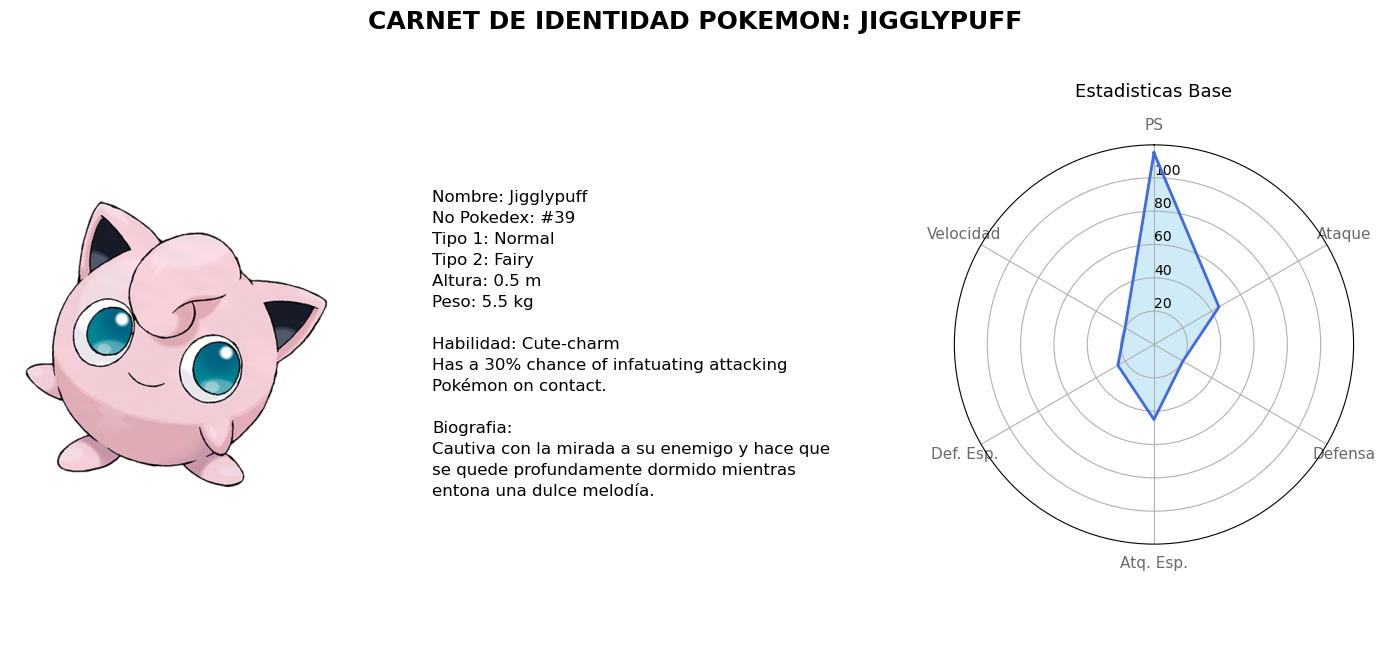

In [17]:
import random

# Elegimos una fila aleatoria del DataFrame
indice_aleatorio = random.randint(0, 150)
pokemon_random = df_kanto.iloc[indice_aleatorio]

print(f"Pokémon elegido: {pokemon_random['nombre'].capitalize()}!\n")

# Creamos su carnet de identidad
crear_carnet(
    nombre=pokemon_random["nombre"],
    pokedex_id=pokemon_random["id"],
    tipo_1=pokemon_random["tipo_1"],
    tipo_2=pokemon_random["tipo_2"],
    altura=pokemon_random["altura"],
    peso=pokemon_random["peso"],
    imagen=pokemon_random["imagen"],
    lista_stats=(pokemon_random["hp"], pokemon_random["attack"], pokemon_random["defense"],
                 pokemon_random["special-attack"], pokemon_random["special-defense"], pokemon_random["speed"]),
    habilidad_nombre=pokemon_random["habilidad_nombre"],
    habilidad_efecto=pokemon_random["habilidad_efecto"],
    descripcion=pokemon_random["descripcion"]
);